### Functional / Taxonomic Analysis using mixed models

In [1]:
import pandas as pd
import numpy as np

In [3]:
merged_df = pd.read_csv("merged_df.csv", sep=";") ### all
merged_df.head(3)

# split data into abundance and annotation data
protein_abundance = merged_df.iloc[:,26:]
protein_annotation = merged_df.iloc[:,0:26]

In [4]:
### load sample annotation
sample_annotation= pd.read_csv("SampleAnnotation(new).csv",sep=";").set_index("Meta-Protein")
sample_annotation.head(5)
print(sample_annotation.T.study.value_counts())

study
Lloyd-Price        446
Lehmann             36
Wolf_2021           36
Wolf_2024_BL        26
Henry               18
Thuy-Boun           18
Wolf_2024_W14-R     14
Wolf_2024_W14-A     12
Name: count, dtype: int64


In [5]:
### Fig2 A-L
### Select all IBD and Control samples from discovery datasets
mask = (sample_annotation.loc["condition"] == "diseased") & (sample_annotation.loc["study"] == "Henry")
henry_diseased =sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["condition"] == "control") & (sample_annotation.loc["study"] == "Henry")
henry_control =sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["condition"] == "diseased") & (sample_annotation.loc["study"] == "Lehmann")
lehmann_diseased = sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["condition"] == "control") & (sample_annotation.loc["study"] == "Lehmann")
lehmann_control = sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["condition"] == "diseased") & (sample_annotation.loc["study"] == "Thuy-Boun")
thuyboun_diseased = sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["condition"] == "control") & (sample_annotation.loc["study"] == "Thuy-Boun")
thuyboun_control = sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["condition"] == "diseased") & (sample_annotation.loc["study"] == "Lloyd-Price") & (sample_annotation.loc["UseCase"] == "BiomarkerDiscovery")
lloydprice_diseased = sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["condition"] == "control") & (sample_annotation.loc["study"] == "Lloyd-Price") & (sample_annotation.loc["UseCase"] == "BiomarkerDiscovery")
lloydprice_control = sample_annotation.columns[mask].tolist()

group_dict = {"Lloydprice (diseased)":lloydprice_diseased, "Lloydprice (control)":lloydprice_control, 
              "Thuyboun (diseased)":thuyboun_diseased, "Thuyboun (control)":thuyboun_control, 
              "Henry (diseased)":henry_diseased, "Henry (control)":henry_control, 
              "Lehmann (diseased)":lehmann_diseased,"Lehmann (control)":lehmann_control, 
              }

In [264]:
### Fig 4F
### Select all CD, UC and Control samples from discovery datasets
mask = (sample_annotation.loc["disease"] == "normal") & (sample_annotation.loc["study"] == "Henry")
henry_normal =sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["disease"] == "UC") & (sample_annotation.loc["study"] == "Henry")
henry_UC =sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["disease"] == "CD") & (sample_annotation.loc["study"] == "Henry")
henry_CD =sample_annotation.columns[mask].tolist()

mask = (sample_annotation.loc["disease"] == "normal") & (sample_annotation.loc["study"] == "Lehmann")
lehmann_normal =sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["disease"] == "UC") & (sample_annotation.loc["study"] == "Lehmann") ### UCa / UCr / UC
lehmann_UC =sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["disease"] == "CD") & (sample_annotation.loc["study"] == "Lehmann")
lehmann_CD =sample_annotation.columns[mask].tolist()

mask = (sample_annotation.loc["disease"] == "normal") & (sample_annotation.loc["study"] == "Thuy-Boun")
thuyboun_normal =sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["disease"] == "UC") & (sample_annotation.loc["study"] == "Thuy-Boun")
thuyboun_UC =sample_annotation.columns[mask].tolist()

mask = (sample_annotation.loc["disease"] == "normal") & (sample_annotation.loc["study"] == "Lloyd-Price") & (sample_annotation.loc["UseCase"] == "BiomarkerDiscovery")
lloydprice_normal = sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["disease"] == "UC") & (sample_annotation.loc["study"] == "Lloyd-Price") & (sample_annotation.loc["UseCase"] == "BiomarkerDiscovery")
lloydprice_UC = sample_annotation.columns[mask].tolist()
mask = (sample_annotation.loc["disease"] == "CD") & (sample_annotation.loc["study"] == "Lloyd-Price") & (sample_annotation.loc["UseCase"] == "BiomarkerDiscovery")
lloydprice_CD = sample_annotation.columns[mask].tolist()


group_dict = {"Lloydprice (normal)":lloydprice_normal,"Lloydprice (UC)":lloydprice_UC,"Lloydprice (CD)":lloydprice_CD,
              "Thuyboun (normal)":thuyboun_normal, "Thuyboun (UC)":thuyboun_UC, 
              "Henry (normal)":henry_normal, "Henry (UC)":henry_UC,"Henry (CD)":henry_CD, 
              "Lehmann (normal)":lehmann_normal,"Lehmann (UC)":lehmann_UC, "Lehmann (CD)":lehmann_CD 
              }

In [246]:
### optional: filter only for bacterial proteins (Figure 2 E-H)
# get only microbial proteins
mask = (merged_df.T.loc["task_1::Taxonomic_Annotation_Task_1::superkingdom"] == "Bacteria")
microbial_protein_abundance = protein_abundance.loc[mask]


In [6]:
# extract the summed abundances of all metaproteins with a given annotation 
def extract_reaction_abundance(samplelist, dataframe,annotation_type, annotation_id):
    protein_abundance=dataframe.loc[:,samplelist]
    # Maske basierend auf der Annotation
    maske = protein_annotation[annotation_type].str.contains(annotation_id, case=False, na=False)
    #add feature to export number of proteins
    # Filtere die entsprechenden Proteine in df_abundanz und summiere über die Samples
    summen = protein_abundance[maske].sum()
    
    
    #print(f"Summierte Abundanzen für Annotation '{ziel_annotation}':")
    #print(summen)
    return summen

In [7]:
print(type(protein_annotation.GroupID[1]))
protein_annotation.GroupID = protein_annotation.GroupID.astype(str)
print(type(protein_annotation.GroupID[1]))

<class 'numpy.int64'>
<class 'str'>


In [ ]:

# functional or taxnomic annotation that should be added (e.g., task_1::Taxonomic_Annotation_Task_1::genus), task_0::Functional_Annotation_Task_1::desc

# Fig 2 A
annotation_list = ["Homo sapiens"]
annotation_type = "task_1::Taxonomic_Annotation_Task_1::species"
# Fig 2 B
annotation_list = ["Faecalibacterium prausnitzii"]
annotation_type = "task_1::Taxonomic_Annotation_Task_1::species"
# Fig 2 C
annotation_list = ["Bacteriodetes"]
annotation_type = "task_1::Taxonomic_Annotation_Task_1::phylum"
# Fig 2 D
annotation_list = ["Viruses"]
annotation_type = "task_1::Taxonomic_Annotation_Task_1::superkingdom"

# Fig 2 E
annotation_list = ['R00238',"R03027","R01778","R01178","R01365","R01174","R01688","R01179","R05576"] # butyrate_fermentation
annotation_type = "Kegg_Reaction"
# Fig 2 F
annotation_list = ["R00315","R00230"] # acetate_fermentation
annotation_type = "Kegg_Reaction"
# Fig 2 G
annotation_list = ["R00930","R00833","R0344","R00342","R01082","R02164","R00928","R00432","R02765","R01859","R11674","R00214","R00217"] # propionate_fermentation
annotation_type = "Kegg_Reaction"
# Fig 2 H
annotation_list = ["R02433","R07136","R00782","R07634","R00897"] # cystein_metabolism
annotation_type = "Kegg_Reaction"
# Fig 2 I
annotation_list = ["GO:1990266"] # neutrophil migration
annotation_type = "GOs"
# Fig 2 J
annotation_list = ["immunoglobulin"]
annotation_type = "task_0::Functional_Annotation_Task_1::desc"
# Fig 2 K
annotation_list = ["GO:0004252"] # serine-type endopeptidase activity
annotation_type = "GOs"
# Fig 2 L
annotation_list = ["GO:0030036"]
annotation_type = "GOs"

#Fig 4F
annotation_list =  ["Annexin A2"] 
annotation_type = "task_0::Functional_Annotation_Task_1::desc"

In [10]:
# for each group in list of patient-batch groups: extract abundance
# create boxplot
pathway_group_abundances = []
group_labels = []

# for each patient group collect and add abundances for each ID, than append to the final list
for key in group_dict:
    group_labels.append(key)
    # set initial zero value array
    group_abundances = np.zeros(len(group_dict[key]))
    for id in annotation_list:
        #group_abundances.append()
        group_abundances=np.add(group_abundances, extract_reaction_abundance(group_dict[key],protein_abundance,annotation_type,id))
    pathway_group_abundances.append(group_abundances)
    

In [11]:
### create input for linear mixed effect modeling
df_abundance = pd.DataFrame(pd.concat(pathway_group_abundances, axis=0).T)*100
df_abundance['sample'] = df_abundance.index

# Fig2 A-L (for IBD vs healthy analysis)
l1 = ["study","condition"]

# Fig 4F (for CD- and UC-specific analysis)
#l1 = ["study","disease"]

disease_study_df = sample_annotation.loc[l1].T
modeling_df = pd.merge(df_abundance, disease_study_df, how='left', left_on='sample', right_on=disease_study_df.index)
modeling_df = modeling_df.rename(columns={modeling_df.columns[0]: "abundance"})
modeling_df

,abundance,sample,study,condition
0,0.175402,160524-SM-A8GT9-17,Lloyd-Price,diseased
1,1.154401,160618-SM-A77V5-63,Lloyd-Price,diseased
2,1.963466,160622-SM-7LLEE-121,Lloyd-Price,diseased
3,0.219901,160624-SM-7DN4P-142,Lloyd-Price,diseased
4,1.768293,160825_SM-7I1HW_216,Lloyd-Price,diseased
...,...,...,...,...
115,1.535540,P13_C,Lehmann,control
116,1.065022,P14_C,Lehmann,control
117,1.377529,P15_C,Lehmann,control
118,1.290926,P16_C,Lehmann,control


In [12]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.tools.sm_exceptions import ConvergenceWarning
### get p-value for each annotation
### linear mixed models with and without healthy/diseased and study as random slope random intercept


# Fig 2A-L
md1=smf.mixedlm("abundance ~ 1 + condition", data = modeling_df, groups=modeling_df["study"], re_formula= "~1 + condition") 

# Fig 4F
#md1=smf.mixedlm("abundance ~ 1 + disease", data = modeling_df, groups=modeling_df["study"], re_formula= "~1 + disease") 

mdf = md1.fit(method=["lbfgs"], reml=False)
print(mdf.summary())
#md1=smf.mixedlm("Abundance ~ 1", data = dataframe, groups=dataframe["Study"], re_formula = "~1 + disease")


                   Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        abundance
No. Observations:        120            Method:                    ML       
No. Groups:              4              Scale:                     0.4364   
Min. group size:         18             Log-Likelihood:            -124.7276
Max. group size:         48             Converged:                 Yes      
Mean group size:         30.0                                               
----------------------------------------------------------------------------
                                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------------------
Intercept                          1.671    0.204  8.199 0.000  1.272  2.071
condition[T.diseased]             -0.669    0.152 -4.402 0.000 -0.966 -0.371
Group Var                          0.118    0.357                           
Group x condition[T

C:\Users\max-w\anaconda3\envs\MetaAnalysis_MachineLearning\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\max-w\anaconda3\envs\MetaAnalysis_MachineLearning\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


In [13]:
# Fig 2A-L
mdf.pvalues["condition[T.diseased]"]

# Fig 4F
#mdf.pvalues["disease[T.normal]"]

# function to transform the p-values in asterics
def get_significance_asterisks(p_value):
    if p_value < 0.001:
        return 'p < 0.001'
    elif p_value < 0.01:
        return 'p < 0.01'
    elif p_value < 0.05:
        return 'p < 0.05'
    else:
        return f"p = {p_value.round(2)}"  # not significant

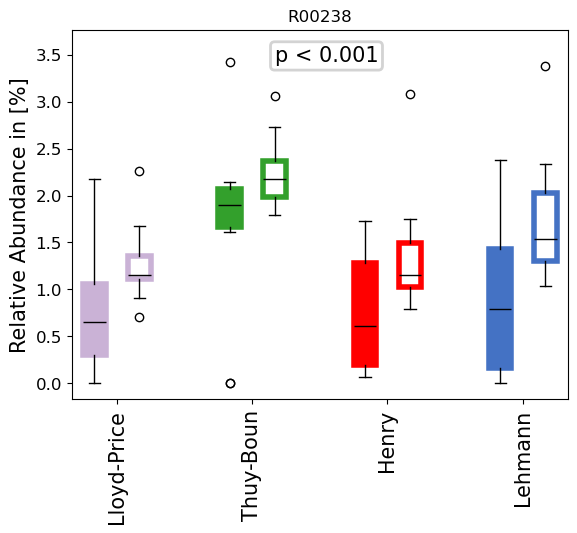

In [36]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import re

fig, ax = plt.subplots()


### Box plot cosmetics

# Fig 2A-L

linecolors = ['#cab2d6', '#cab2d6', '#33a02c','#33a02c', '#ff0000', '#ff0000','#4472c4', '#4472c4']
colors = ['#cab2d6', 'white', '#33a02c','white', '#ff0000', 'white','#4472c4', 'white']
box_positions=[1, 2, 4, 5, 7, 8, 10, 11]
labels = ["Lloyd-Price", "Thuy-Boun",'Henry', 'Lehmann']


# Fig 4F
#linecolors = ['#cab2d6', '#cab2d6', '#cab2d6', '#33a02c', '#33a02c','#33a02c', '#ff0000', '#ff0000', '#ff0000','#4472c4','#4472c4', '#4472c4']
#colors = ['white', '#cab2d6', '#cab2d6','white','#33a02c','#33a02c',  '#ff0000','#ff0000','#ff0000', 'white','#4472c4','#4472c4']
#box_positions=[1, 2, 3, 4, 5, 6, 7, 8]
#labels = ["Healthy", "UC", "CD","Healthy", "UC","CD", "UC", "CD"]


### get data (Abundance & Significane
new_pathway_group_abundances = [i * 100 for i in pathway_group_abundances]
# Fig 2 A-L
sig = get_significance_asterisks(mdf.pvalues["condition[T.diseased]"])
#sig = get_significance_asterisks(mdf.pvalues["disease[T.normal]"])

bplot = ax.boxplot(new_pathway_group_abundances, positions=box_positions,
                   patch_artist=True,  # fill with color
                  )
# Set colors for lines and boxes
for box, color in zip(bplot['boxes'], linecolors):
    box.set(color=color, linewidth=4)
for median in bplot['medians']:
    median.set_color('black')
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

### y axis
# set y axis label & limit 
ax.set_ylabel('Relative Abundance in [%]', fontsize=15)
ax.set_ylim(top= max(modeling_df.abundance)*1.1)
plt.yticks(fontsize=12)


### x axis
#ax.set_xticklabels(labels) #lables
# Fig 2 A-L (x tick lables are different studies --> placement in the middle of the boxes of each study)
midpoints = [np.mean(box_positions[0:2]), np.mean(box_positions[2:4]),np.mean(box_positions[4:6]),np.mean(box_positions[6:8])]
ax.set_xticks(midpoints)
ax.set_xticklabels(labels,fontsize=15)

plt.xticks(rotation=90)



### Fig 2A-L
### Ad text for significance
ax.text(
    5, max(modeling_df.abundance),                     # (x, y)-Position im Plot
    f"{sig}",         # Inhalt der Box
    fontsize=15,
    color='black',
    bbox=dict(
        facecolor='white',  # Hintergrundfarbe
        edgecolor='lightgrey',       # Rahmenfarbe
        boxstyle='round,pad=0.2', # Box-Stil
        linewidth=2
    ))



### Figure size (for saving)
#def set_size(w,h, ax=None):
#    """ w, h: width, height in inches """
#    if not ax: ax=plt.gca()
#    l = ax.figure.subplotpars.left
#    r = ax.figure.subplotpars.right
#    t = ax.figure.subplotpars.top
#    b = ax.figure.subplotpars.bottom
#    figw = float(w)/(r-l)
#    figh = float(h)/(t-b)
#    ax.figure.set_size_inches(figw, figh)          
#set_size(5.8,6.2)


plt.title(annotation_list[0])
plt.savefig(f"{re.sub(r'[:]', '', annotation_list[0])}.png", bbox_inches="tight")
plt.show()
